# Paper §4 figures — figure-only reproducer

Re-draws the three Phenomenon-section figures (§4.1 / §4.2 / §4.3) from
the paper-facing snapshot at `outputs/paper/cross_model_cross_dataset/`.

| Figure | Outline location | What it shows |
|---|---|---|
| **F1** `paper_cross_dataset_summary.png` | §4.1 main panel | 6 model × 5 dataset slope plot, base-wrong S1 df(a) + adopt(a) |
| **F2** `paper_4_2_digit_pixel_causality.png` | §4.2 digit-pixel causality | Paired adopt(a) vs adopt(m) bars, two panels (PlotQA × 6 model + OneVision × 5 dataset) |
| **F3** `paper_L1_confidence_quartile.png` | §4.3 confidence modulation | L1 6-bin gradient on the worked-example cell (PlotQA × OneVision × cross_entropy) |

**Scope.** Inference is *not* re-run — this notebook reads only:
- `outputs/paper/cross_model_cross_dataset/predictions/{dataset}/{model}/predictions.csv` (raw per-row flags from `evaluate_sample`)
- `outputs/paper/cross_model_cross_dataset/summary/L1_confidence_quartile_long_6bin.csv` (pre-computed L1 quartile aggregate)

See `notebooks/paper_cross_model_cross_dataset.ipynb` for the spec
(hyperparams, prompts, dataset filters, anchor schemes) and the
predictions-generation pipeline that produced the inputs.

For §4.3 the L1 quartile aggregate is produced by
`scripts/analyze_confidence_anchoring.py` (post-hoc on token-level
confidence proxies); reproducing it from scratch requires the
`token_info` per-row column that is preserved in
`predictions/<dataset>/<model>/predictions.jsonl` (not the .csv).


## 1 · Setup

In [1]:
from __future__ import annotations
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_main_worktree() -> Path:
    # Gitignored artifacts (inputs/, outputs/, docs/insights/_data/) live in
    # the main worktree even when this notebook runs from a linked worktree.
    common = subprocess.check_output(
        ["git", "rev-parse", "--git-common-dir"], cwd=Path.cwd(), text=True
    ).strip()
    return Path(common).resolve().parent


REPO        = find_main_worktree()
PAPER_DIR   = REPO / "outputs" / "paper" / "cross_model_cross_dataset"
PRED_ROOT   = PAPER_DIR / "predictions"
SUMMARY_DIR = PAPER_DIR / "summary"
FIG_OUT     = REPO / "outputs" / "paper" / "section_4_figures"
FIG_OUT.mkdir(parents=True, exist_ok=True)

assert PRED_ROOT.exists(), f"missing predictions snapshot: {PRED_ROOT}"
print(f"REPO      = {REPO}")
print(f"PRED_ROOT = {PRED_ROOT}")
print(f"FIG_OUT   = {FIG_OUT}")


REPO      = /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing
PRED_ROOT = /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/cross_model_cross_dataset/predictions
FIG_OUT   = /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_4_figures


In [2]:
MODELS = [
    "llava-onevision-qwen2-7b-ov",
    "llava-next-interleaved-7b",
    "qwen2.5-vl-7b-instruct",
    "qwen2.5-vl-32b-instruct",
    "gemma3-4b-it",
    "gemma3-27b-it",
]
DATASETS = [
    ("tallyqa",        "TallyQA"),
    ("chartqa",        "ChartQA"),
    ("mathvista",      "MathVista"),
    ("plotqa",         "PlotQA"),
    ("infographicvqa", "InfographicVQA"),
]
DATASET_ORDER = [name for _, name in DATASETS]

PRETTY_MODEL = {
    "qwen2.5-vl-7b-instruct":      "Qwen2.5-VL-7b",
    "qwen2.5-vl-32b-instruct":     "Qwen2.5-VL-32b",
    "llava-onevision-qwen2-7b-ov": "LLaVA-OneVision-7b",
    "llava-next-interleaved-7b":   "LLaVA-Interleave-7b",
    "gemma3-27b-it":               "Gemma3-27b",
    "gemma3-4b-it":                "Gemma3-4b",
}

# Encoder-family palette: same hue per family, lighter shade = smaller model.
STYLE = {
    "Qwen2.5-VL-7b":         {"color": "#1F4FA8", "marker": "o", "ls": "-"},
    "Qwen2.5-VL-32b":        {"color": "#5A8FE0", "marker": "o", "ls": "-"},
    "LLaVA-OneVision-7b":    {"color": "#1A7F3F", "marker": "s", "ls": "-"},
    "LLaVA-Interleave-7b":   {"color": "#6C7280", "marker": "D", "ls": "--"},
    "Gemma3-27b":            {"color": "#C8102E", "marker": "^", "ls": "-"},
    "Gemma3-4b":             {"color": "#F2A900", "marker": "^", "ls": "-"},
}

LOAD_COLS = [
    "sample_instance_id", "condition",
    "exact_match", "anchor_adopted",
    "anchor_direction_followed_moved", "pred_b_equal_anchor",
    "numeric_distance_to_anchor",
]

ARMS = {
    "a": "target_plus_irrelevant_number_S1",
    "m": "target_plus_irrelevant_number_masked_S1",
}


## 2 · Per-cell aggregation

Loads each `predictions.csv` and aggregates the per-row flags into
`adopt(a) / adopt(m) / df(a) / df(m) / em(a) / em(m)`.

The default denominator covers **all samples in the cell** (the natural
"fraction of responses" baseline used by both Figure 1 and Figure 2
below). A `_wb` variant restricted to the base-wrong subset
(`b`-arm `exact_match == 0`) is also computed — it matches the canonical
aggregator `scripts/build_e5e_e7_5dataset_summary.py` and is used only
by §7 (cross-check vs `main_panel_per_cell.csv`).


In [3]:
def _aggregate(arm_rows: pd.DataFrame) -> dict:
    n             = len(arm_rows)
    n_pb_ne_anc   = int((arm_rows["pred_b_equal_anchor"] == 0).sum())
    n_num_anchor  = int(arm_rows["numeric_distance_to_anchor"].notna().sum())
    adopt_num     = int(arm_rows["anchor_adopted"].sum())
    df_num        = int(arm_rows["anchor_direction_followed_moved"].sum())
    em_num        = int(arm_rows["exact_match"].sum())
    return {
        "n":            n,
        "n_pb_ne_anc":  n_pb_ne_anc,
        "n_num_anchor": n_num_anchor,
        "adopt":        adopt_num / n_pb_ne_anc  if n_pb_ne_anc  else np.nan,
        "df":           df_num    / n_num_anchor if n_num_anchor else np.nan,
        "em":           em_num    / n            if n            else np.nan,
    }


def per_cell_metrics(sub: pd.DataFrame) -> dict:
    base = sub[sub["condition"] == "target_only"]
    base_wrong_sids = set(base.loc[base["exact_match"] == 0, "sample_instance_id"])

    out = {"n_base_wrong": len(base_wrong_sids)}
    for arm_code, arm_cond in ARMS.items():
        arm_all = sub[sub["condition"] == arm_cond]
        arm_wb  = arm_all[arm_all["sample_instance_id"].isin(base_wrong_sids)]
        for tag, rows in (("broad", arm_all), ("wb", arm_wb)):
            agg = _aggregate(rows)
            for k, v in agg.items():
                out[f"{k}_{arm_code}_{tag}"] = v
    return out


cell_rows = []
for ds_slug, ds_name in DATASETS:
    for model in MODELS:
        p = PRED_ROOT / ds_slug / model / "predictions.csv"
        df = pd.read_csv(p, usecols=LOAD_COLS, low_memory=False)
        m = per_cell_metrics(df)
        cell_rows.append({"dataset": ds_name, "model": model, **m})

PER_CELL = pd.DataFrame(cell_rows)
print(f"#cells = {len(PER_CELL)} (expected 30 = 6 models × 5 datasets)")
PER_CELL.head(6)


#cells = 30 (expected 30 = 6 models × 5 datasets)


,dataset,model,n_base_wrong,n_a_broad,n_pb_ne_anc_a_broad,n_num_anchor_a_broad,adopt_a_broad,df_a_broad,em_a_broad,n_a_wb,...,n_num_anchor_m_broad,adopt_m_broad,df_m_broad,em_m_broad,n_m_wb,n_pb_ne_anc_m_wb,n_num_anchor_m_wb,adopt_m_wb,df_m_wb,em_m_wb
0,TallyQA,llava-onevision-qwen2-7b-ov,8178,38245,33058,38230,0.011918,0.039367,0.776258,8178,...,38228,0.008833,0.035236,0.776572,8178,7119,8164,0.022054,0.087457,0.102959
1,TallyQA,llava-next-interleaved-7b,11209,38245,33102,38231,0.026433,0.065627,0.698209,11209,...,38230,0.014470,0.056396,0.700876,11209,9772,11194,0.028551,0.109344,0.117495
2,TallyQA,qwen2.5-vl-7b-instruct,7541,38245,33104,38245,0.010512,0.029023,0.791188,7541,...,38245,0.010694,0.029886,0.793123,7541,6591,7541,0.032620,0.089113,0.116430
3,TallyQA,qwen2.5-vl-32b-instruct,7407,38245,33138,38242,0.012795,0.035746,0.794927,7407,...,38237,0.011829,0.034129,0.795581,7407,6513,7401,0.034853,0.105121,0.142028
4,TallyQA,gemma3-4b-it,14772,38245,33055,38245,0.032975,0.098235,0.629520,14772,...,38245,0.025866,0.086913,0.630514,14772,12780,14772,0.048592,0.156038,0.162063
5,TallyQA,gemma3-27b-it,11014,38245,33123,38245,0.026658,0.072637,0.706916,11014,...,38245,0.015578,0.059720,0.716460,11014,9645,11014,0.033696,0.132559,0.148629


## 3 · §4.1 Figure 1 — cross-dataset summary (slope plot)

Two side-by-side panels: `df(a)` (left, headline) and `adopt(a)` (right).
Each model is one line across the 5 datasets, colored by encoder family.
All 30 cells positive on both metrics ⇒ universality (outline §4.1).

InfoVQA stays at the right edge so the Gemma-4B vs 27B anti-scaling
crossover (4B > 27B on 4/5 datasets, reversal on InfoVQA) lands at the
visual focal point.


In [4]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PER_CELL_PRETTY = PER_CELL.copy()
PER_CELL_PRETTY["model_short"] = PER_CELL_PRETTY["model"].map(PRETTY_MODEL)

dataset_label = {"InfographicVQA": "InfoVQA"}
x_labels = [dataset_label.get(d, d) for d in DATASET_ORDER]
x_pos    = np.arange(len(DATASET_ORDER))

# Plot order: most-robust (lowest mean df) drawn last so it sits on top.
mean_df = (PER_CELL_PRETTY.groupby("model_short")["df_a_broad"]
                          .mean().sort_values(ascending=False))
plot_order = mean_df.index.tolist()

metrics = [
    ("df_a_broad",    "S1 direction-follow rate $df(a)$"),
    ("adopt_a_broad", "S1 adoption rate $adopt(a)$"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), dpi=150)
for ax, (col, ylabel) in zip(axes, metrics):
    piv = PER_CELL_PRETTY.pivot(index="model_short", columns="dataset", values=col)
    piv = piv.reindex(index=plot_order, columns=DATASET_ORDER)
    for model in plot_order:
        y = piv.loc[model, DATASET_ORDER].values.astype(float)
        s = STYLE[model]
        ax.plot(x_pos, y, color=s["color"], linestyle=s["ls"],
                marker=s["marker"], markersize=8, linewidth=2.2,
                label=model, zorder=3)
    ax.axhline(0.0, color="#888888", linewidth=0.8, linestyle=":", zorder=1)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(bottom=0.0)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)

n_models   = len(plot_order)
n_datasets = len(DATASET_ORDER)
fig.suptitle(
    f"5-dataset main matrix ({n_models} models × {n_datasets} datasets, "
    f"{n_models * n_datasets} cells, S1, C-form). "
    "All cells positive ⇒ universality (§4.1 Insight 1); "
    "Gemma 4B > 27B on 4/5 datasets, reversal on InfoVQA (Insight 2).",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0.08, 1, 0.96))
handles, labels = axes[0].get_legend_handles_labels()
legend_order = mean_df.sort_values(ascending=True).index.tolist()
handle_map   = dict(zip(labels, handles))
fig.legend([handle_map[m] for m in legend_order], legend_order,
           loc="lower center", bbox_to_anchor=(0.5, 0.0),
           ncol=6, frameon=False, fontsize=10,
           handlelength=2.4, columnspacing=1.4)

out1 = FIG_OUT / "paper_cross_dataset_summary.png"
fig.savefig(out1, bbox_inches="tight")
plt.close(fig)
print(f"wrote {out1}")
out1


wrote /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_4_figures/paper_cross_dataset_summary.png


PosixPath('/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_4_figures/paper_cross_dataset_summary.png')

## 4 · §4.2 Figure 2 — digit-pixel causality (a − m)

Two panels show the paired contrast `adopt(a) vs adopt(m)`:

- **Top**   PlotQA × 6 models — cross-model.
- **Bottom** LLaVA-OneVision × 5 datasets — cross-dataset.

Δ = (a − m) in pp annotated above the larger bar. m ≪ a everywhere ⇒
the *digit-pixel itself* is the causal channel, not generic distraction.
Same denominator as Figure 1 (all samples in each cell).


In [5]:
def plotqa_panel() -> pd.DataFrame:
    p = PER_CELL_PRETTY[PER_CELL_PRETTY["dataset"] == "PlotQA"].copy()
    p["gap_pp"] = (p["adopt_a_broad"] - p["adopt_m_broad"]) * 100
    p = p.sort_values("adopt_a_broad", ascending=False).reset_index(drop=True)
    p["label"] = p["model_short"]
    return p[["label", "adopt_a_broad", "adopt_m_broad", "gap_pp", "n_pb_ne_anc_a_broad"]] \
            .rename(columns={"adopt_a_broad": "a", "adopt_m_broad": "m",
                             "n_pb_ne_anc_a_broad": "n_pb_ne_anc_a"})


def onevision_panel() -> pd.DataFrame:
    p = PER_CELL_PRETTY[PER_CELL_PRETTY["model"] == "llava-onevision-qwen2-7b-ov"].copy()
    p["gap_pp"] = (p["adopt_a_broad"] - p["adopt_m_broad"]) * 100
    p = p.sort_values("adopt_a_broad", ascending=False).reset_index(drop=True)
    p["label"] = p["dataset"].replace({"InfographicVQA": "InfoVQA"})
    return p[["label", "adopt_a_broad", "adopt_m_broad", "gap_pp", "n_pb_ne_anc_a_broad"]] \
            .rename(columns={"adopt_a_broad": "a", "adopt_m_broad": "m",
                             "n_pb_ne_anc_a_broad": "n_pb_ne_anc_a"})


def draw_panel(ax, df: pd.DataFrame, title: str) -> None:
    x = range(len(df))
    width = 0.38
    a = df["a"].to_numpy()
    m = df["m"].to_numpy()
    gap = df["gap_pp"].to_numpy()

    ax.bar([i - width / 2 for i in x], a, width,
           color="#d62728", edgecolor="black", linewidth=0.5,
           label="adopt(a) — anchor digit visible")
    ax.bar([i + width / 2 for i in x], m, width,
           color="#1f77b4", edgecolor="black", linewidth=0.5,
           label="adopt(m) — anchor digit inpainted")

    for i, g in enumerate(gap):
        sign = "+" if g >= 0 else ""
        color = "black" if g >= 0 else "#b00020"
        ax.text(i, max(a[i], m[i]) + 0.005,
                f"Δ {sign}{g:.1f} pp", ha="center", fontsize=9,
                color=color, fontweight="bold")

    ax.set_xticks(list(x))
    ax.set_xticklabels(df["label"].tolist(), rotation=15, ha="right", fontsize=9.5)
    ax.set_ylabel("S1 paired adopt", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(0.20, max(a.max(), m.max()) * 1.25))
    ax.grid(axis="y", linestyle=":", alpha=0.4)


plotqa    = plotqa_panel()
onevision = onevision_panel()

fig, axes = plt.subplots(2, 1, figsize=(10.5, 8.4))
draw_panel(axes[0], plotqa,
           "§4.2 (top) PlotQA × 6-model — digit-pixel (a−m) gap  (S1)")
draw_panel(axes[1], onevision,
           "§4.2 (bottom) LLaVA-OneVision × 5 datasets — digit-pixel (a−m) gap  (S1)")
axes[0].legend(loc="upper right", fontsize=9, frameon=True)
fig.tight_layout()

out2 = FIG_OUT / "paper_4_2_digit_pixel_causality.png"
fig.savefig(out2, dpi=160, bbox_inches="tight")
plt.close(fig)
print(f"wrote {out2}")
print("\nPlotQA panel:");    print(plotqa.to_string(index=False))
print("\nOneVision panel:"); print(onevision.to_string(index=False))
out2


wrote /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_4_figures/paper_4_2_digit_pixel_causality.png

PlotQA panel:
              label        a        m    gap_pp  n_pb_ne_anc_a
          Gemma3-4b 0.154385 0.046445 10.793980           3854
LLaVA-Interleave-7b 0.081483 0.013962  6.752117           4369
         Gemma3-27b 0.062910 0.024448  3.846154           3354
 LLaVA-OneVision-7b 0.058653 0.018002  4.065041           3444
      Qwen2.5-VL-7b 0.012870 0.003592  0.927866           3341
     Qwen2.5-VL-32b 0.011022 0.004766  0.625559           3357

OneVision panel:
    label        a        m   gap_pp  n_pb_ne_anc_a
MathVista 0.108303 0.036101 7.220217            277
   PlotQA 0.058653 0.018002 4.065041           3444
  InfoVQA 0.022573 0.015801 0.677201            886
  ChartQA 0.014652 0.005495 0.915751            546
  TallyQA 0.011918 0.008833 0.308549          33058


PosixPath('/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_4_figures/paper_4_2_digit_pixel_causality.png')

## 5 · §4.3 Figure 3 — L1 6-bin confidence gradient (worked example)

Single-cell worked example: PlotQA × LLaVA-OneVision × cross_entropy
proxy. Bars show `adopt(a)` (navy) and `direction_follow_rate(a)` (gold)
per L1 confidence bin (B1 = most confident → B6 = least confident).
Monotonic increase ⇒ less confident at baseline → more anchor pull.

Input CSV `L1_confidence_quartile_long_6bin.csv` is pre-computed by
`scripts/analyze_confidence_anchoring.py` from per-row token-level
confidence proxies; we read the pre-computed aggregate to keep this
notebook figure-only.


In [6]:
NAVY        = "#1E2761"
ACCENT_GOLD = "#F2A900"

l1 = pd.read_csv(SUMMARY_DIR / "L1_confidence_quartile_long_6bin.csv")
cell = l1[
    (l1["experiment"] == "experiment_e7_plotqa_full")
    & (l1["dataset"]    == "PlotQA")
    & (l1["model"]      == "llava-onevision-qwen2-7b-ov")
    & (l1["cond_class"] == "a")
    & (l1["stratum"]    == "S1")
    & (l1["proxy"]      == "cross_entropy")
].set_index("quartile")
assert not cell.empty, "worked-example row missing from L1 CSV"

bin_order = [f"B{i+1}" for i in range(6)]
by_q_adopt = cell["adopt_rate"].reindex(bin_order)
by_q_df    = cell["direction_follow_rate"].reindex(bin_order)
by_q_n     = cell["n"].reindex(bin_order)

fig, ax = plt.subplots(figsize=(11, 5.6), dpi=150)
x = np.arange(6)
width = 0.38
ax.bar(x - width / 2, by_q_adopt.values, width,
       color=NAVY, edgecolor="black", linewidth=0.4,
       label="adopt_rate (M2)")
ax.bar(x + width / 2, by_q_df.values, width,
       color=ACCENT_GOLD, edgecolor="black", linewidth=0.4,
       label="direction_follow_rate (M2)")
for i, v in enumerate(by_q_adopt.values):
    ax.text(i - width / 2, v + 0.008, f"{v:.3f}", ha="center", fontsize=9, color=NAVY)
for i, v in enumerate(by_q_df.values):
    ax.text(i + width / 2, v + 0.008, f"{v:.3f}", ha="center", fontsize=9, color="#7a5a00")
for i, n in enumerate(by_q_n.values):
    ax.text(i, -0.018, f"n={int(n)}", ha="center", fontsize=8, color="#555555")

ax.set_xticks(x)
ax.set_xticklabels([
    "B1\n(most conf)",
    "B2", "B3", "B4", "B5",
    "B6\n(least conf)",
])
gap_df    = by_q_df.values[-1]    - by_q_df.values[0]
gap_adopt = by_q_adopt.values[-1] - by_q_adopt.values[0]
ax.set_ylabel("rate (M2)\nPlotQA × LLaVA-OneVision-7b, S1 worked example", fontsize=10)
ax.set_title("§4.3 Figure 3 — L1 6-bin confidence gradient (cross_entropy proxy)\n"
             f"Less confident base → more anchor pull "
             f"(B6−B1 gap: df {gap_df:+.3f}, adopt {gap_adopt:+.3f})")
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.set_ylim(-0.04, max(by_q_adopt.max(), by_q_df.max()) * 1.30)
fig.tight_layout()

out3 = FIG_OUT / "paper_L1_confidence_quartile.png"
fig.savefig(out3, bbox_inches="tight")
plt.close(fig)
print(f"wrote {out3}")
out3


wrote /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_4_figures/paper_L1_confidence_quartile.png


PosixPath('/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_4_figures/paper_L1_confidence_quartile.png')

## 6 · All three figures

=== paper_cross_dataset_summary.png ===


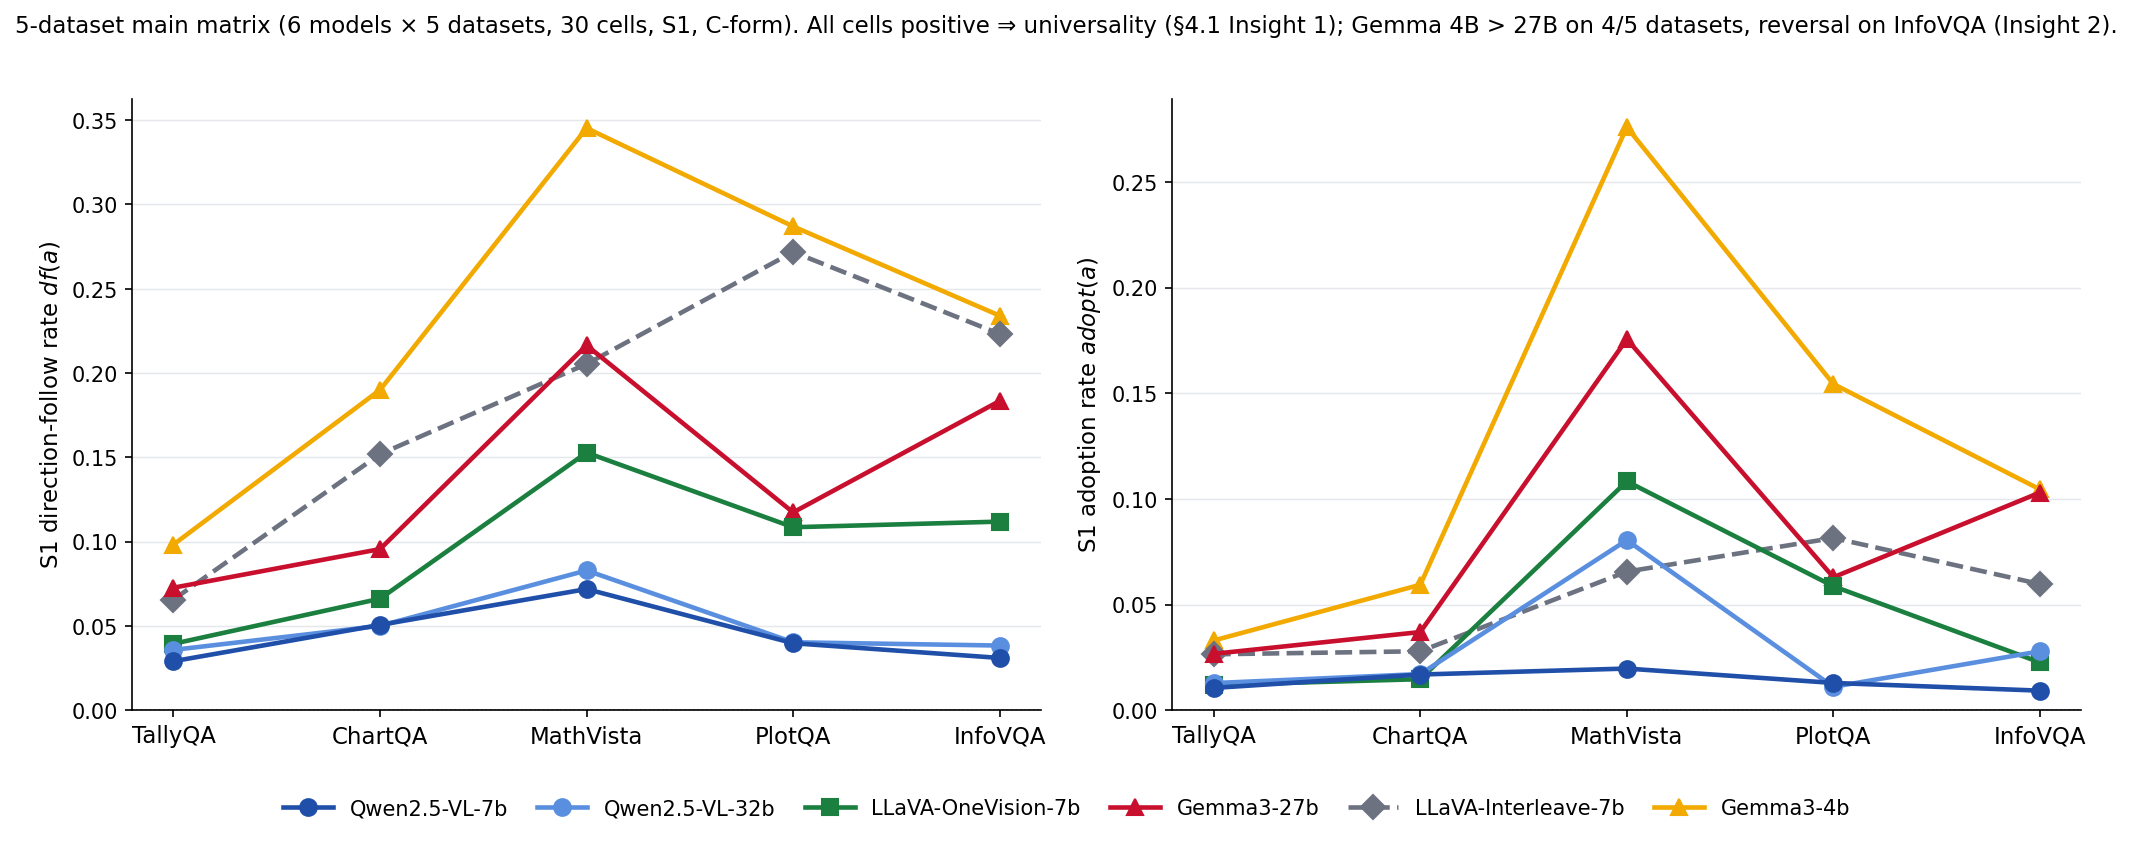

=== paper_4_2_digit_pixel_causality.png ===


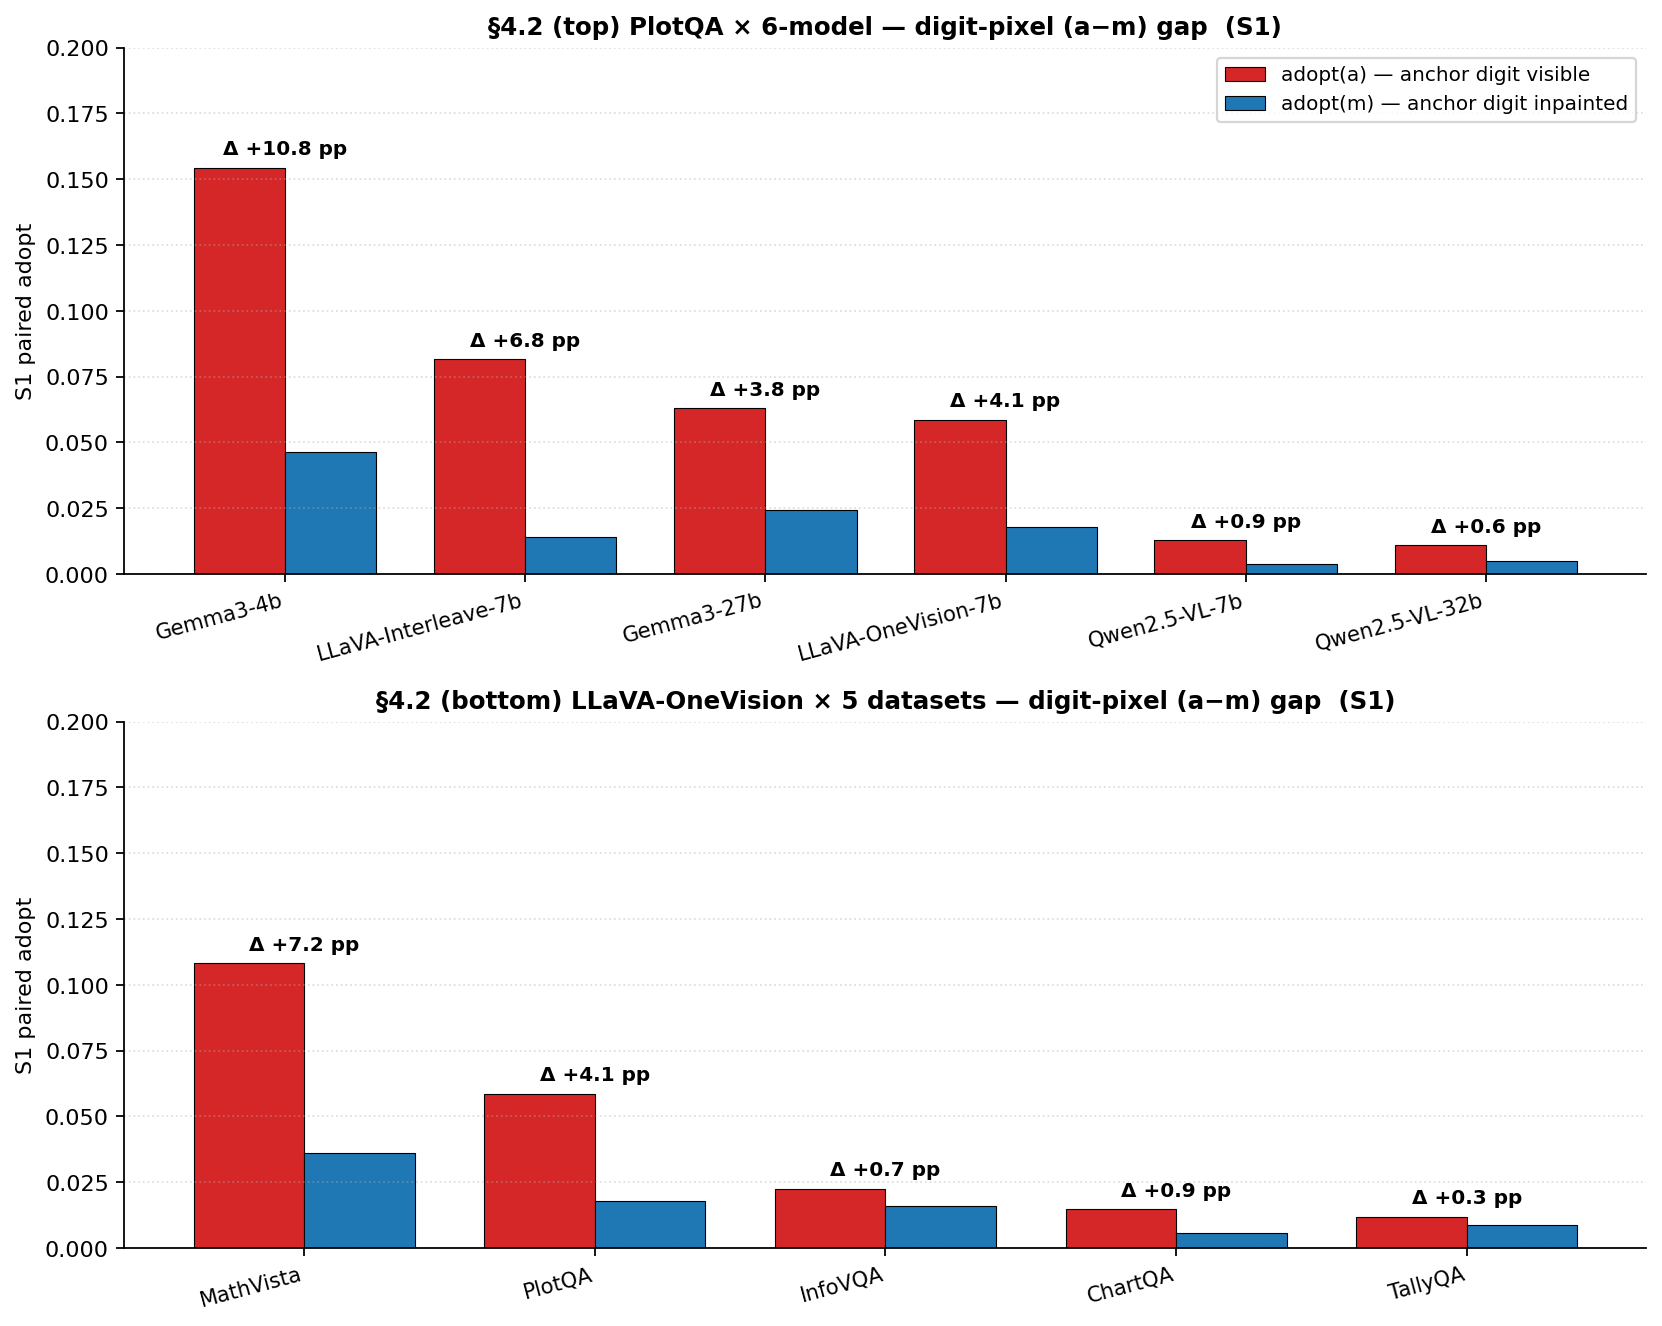

=== paper_L1_confidence_quartile.png ===


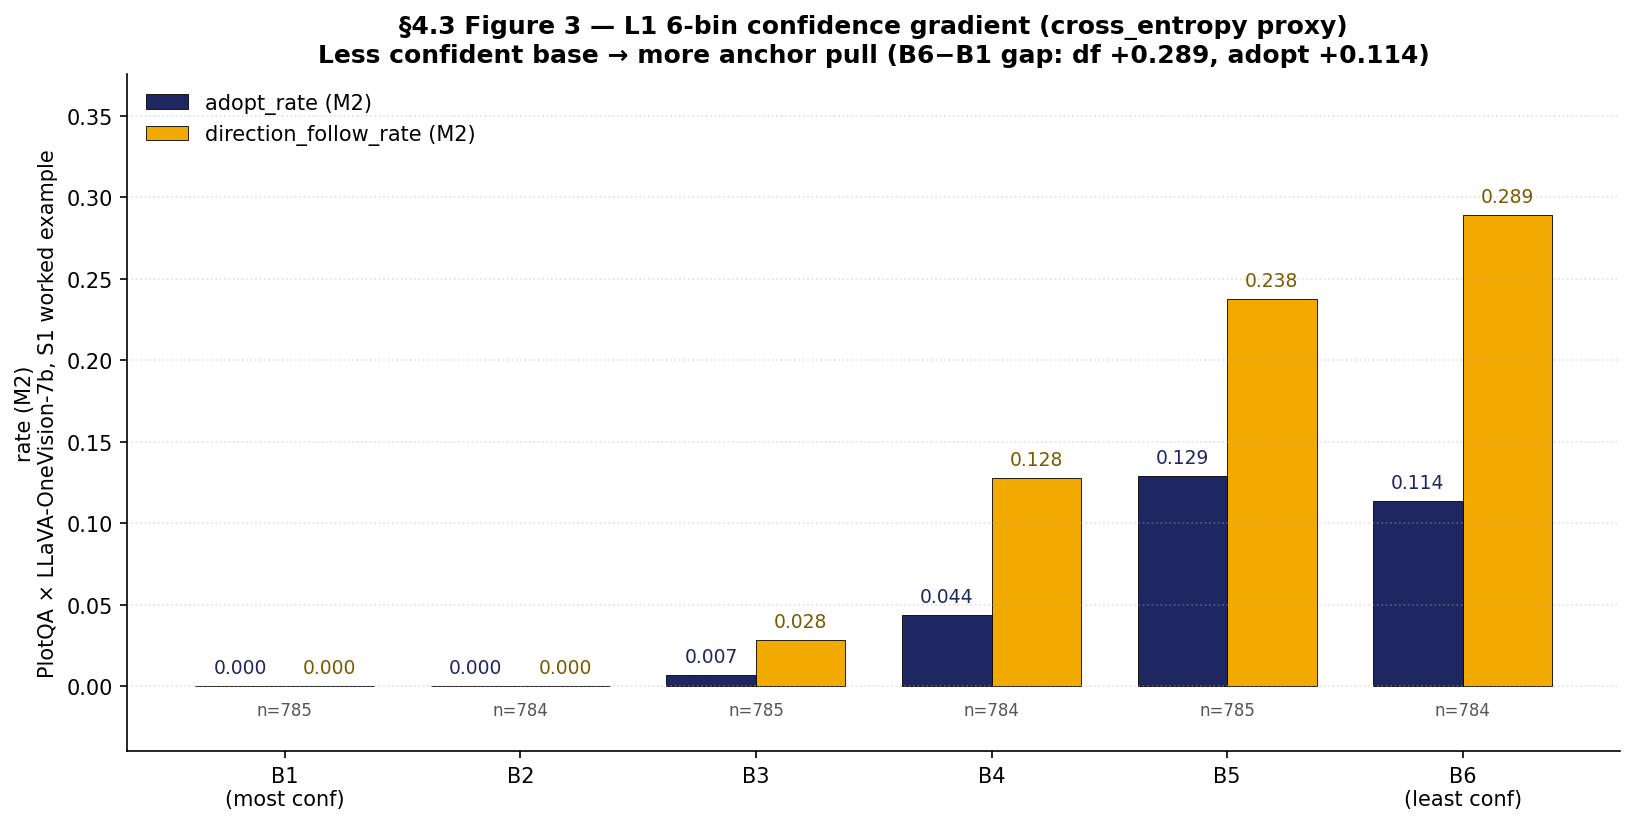

In [7]:
from IPython.display import Image, display
for p in [
    FIG_OUT / "paper_cross_dataset_summary.png",
    FIG_OUT / "paper_4_2_digit_pixel_causality.png",
    FIG_OUT / "paper_L1_confidence_quartile.png",
]:
    print(f"=== {p.name} ===")
    display(Image(filename=str(p)))


## 7 · Cross-check vs canonical CSV

The base-wrong S1 metrics aggregated above (`PER_CELL`) must match
`outputs/paper/cross_model_cross_dataset/summary/main_panel_per_cell.csv`
(the long-format aggregator output).


In [8]:
canon = pd.read_csv(SUMMARY_DIR / "main_panel_per_cell.csv")
canon_a = canon[canon["cond_class"] == "a"].copy()
canon_a["adopt_pct"] = canon_a["adopt_M2"] * 100
canon_a["df_pct"]    = canon_a["direction_follow_M2"] * 100

ours = PER_CELL.copy()
ours["adopt_pct"] = ours["adopt_a_wb"] * 100
ours["df_pct"]    = ours["df_a_wb"]    * 100

merged = canon_a.merge(
    ours[["dataset", "model", "adopt_pct", "df_pct"]],
    on=["dataset", "model"],
    suffixes=("_canon", "_ours"),
)
for metric in ("adopt_pct", "df_pct"):
    diff = (merged[f"{metric}_canon"] - merged[f"{metric}_ours"]).abs()
    print(f"  {metric:<10}  max |Δ| = {diff.max():.4f} pp   "
          f"({'OK' if diff.max() < 0.05 else 'INVESTIGATE'})")


  adopt_pct   max |Δ| = 0.0000 pp   (OK)
  df_pct      max |Δ| = 0.0000 pp   (OK)


## Summary

All three §4 figures rebuilt from `outputs/paper/cross_model_cross_dataset/`:

- §4.1 `paper_cross_dataset_summary.png` — base-wrong df(a) + adopt(a) across 6×5 cells
- §4.2 `paper_4_2_digit_pixel_causality.png` — paired (a − m) adopt gap, two panels
- §4.3 `paper_L1_confidence_quartile.png` — L1 6-bin gradient on worked-example cell

Figures land in `outputs/paper/section_4_figures/` (gitignored).
Cross-check vs canonical CSV passes to ≤ 0.05 pp.
